# **CHAPTER 15 Processing Sequences Using RNNs and CNNs**

| Forecasting Horizon        | Model          |         MAE ↓ |        RMSE ↓ |     MAPE ↓ | Parameters | Training Time |
| -------------------------- | -------------- | ------------: | ------------: | ---------: | ---------: | ------------: |
| **15 Minutes**             | Simple RNN     |     1.1775 kW |     2.5615 kW |     29.07% |      1,857 |        10 min |
|                            | LSTM           |     1.0220 kW |     2.1476 kW |     28.34% |     31,649 |   07:42–07:55 |
|                            | GRU            |     0.9973 kW |     2.0873 kW |     27.23% |      4,577 |   07:56–08:00 |
|                            | Transformer    |     0.9690 kW |     2.0522 kW |     29.31% |     17,921 |   10:19–10:30 |
| **1 Hour (4 × 15-min)**    | **Simple RNN** | **1.2169 kW** | **2.5247 kW** | **34.92%** |  **1,908** |             — |
|                            | LSTM           |     1.2599 kW |     2.6087 kW |      19.4% |     31,700 |             — |
|                            | GRU            |     1.2293 kW |     2.5295 kW |      21.9% |      4,628 |             — |
|                            | Transformer    |     1.2175 kW |     2.5314 kW |     35.56% |     17,972 |             — |
| **24 Hours (96 × 15-min)** | **Simple RNN** | **1.7076 kW** | **3.3263 kW** | **51.02%** |  **3,472** |             — |
|                            | LSTM           |     2.0930 kW |     3.6223 kW |     69.65% |     33,264 |             — |
|                            | GRU            |     1.8711 kW |     3.4292 kW |     57.74% |      6,192 |             — |
|                            | Transformer    |     1.7487 kW |     3.3825 kW |     50.04% |     19,536 |             — |


In [1]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorboard
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers
from sklearn.datasets import load_sample_image
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_olivetti_faces
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


## **ElectricityLoadDiagrams20112014 Dataset**  -->  **UCI**

In [3]:
df = pd.read_csv("/content/drive/MyDrive/LD2011_2014.txt", sep=";", parse_dates=[0])

print(df.head())
print(df.shape)
print(df.columns[:10])
print(df.dtypes[:10])

/tmp/ipykernel_706/697275784.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,125,126,127,128,129,130,131,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,157,160,164,165,167,170,173,177,178,179,181,184,185,186,223,224,255,280,289,305,308,322,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,363,364,365,366,367,368,369,370) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/LD2011_2014.txt", sep=";", parse_dates=[0])


           Unnamed: 0 MT_001 MT_002 MT_003 MT_004 MT_005 MT_006 MT_007 MT_008  \
0 2011-01-01 00:15:00      0      0      0      0      0      0      0      0   
1 2011-01-01 00:30:00      0      0      0      0      0      0      0      0   
2 2011-01-01 00:45:00      0      0      0      0      0      0      0      0   
3 2011-01-01 01:00:00      0      0      0      0      0      0      0      0   
4 2011-01-01 01:15:00      0      0      0      0      0      0      0      0   

  MT_009  ... MT_361 MT_362 MT_363 MT_364 MT_365 MT_366 MT_367 MT_368 MT_369  \
0      0  ...      0    0.0      0      0      0      0      0      0      0   
1      0  ...      0    0.0      0      0      0      0      0      0      0   
2      0  ...      0    0.0      0      0      0      0      0      0      0   
3      0  ...      0    0.0      0      0      0      0      0      0      0   
4      0  ...      0    0.0      0      0      0      0      0      0      0   

  MT_370  
0      0  
1      0  

In [4]:
df = df.rename(columns={"Unnamed: 0": "timestamp"})

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
print(df.head(5))

(140256, 371)
            timestamp MT_001 MT_002 MT_003 MT_004 MT_005 MT_006 MT_007 MT_008  \
0 2011-01-01 00:15:00      0      0      0      0      0      0      0      0   
1 2011-01-01 00:30:00      0      0      0      0      0      0      0      0   
2 2011-01-01 00:45:00      0      0      0      0      0      0      0      0   
3 2011-01-01 01:00:00      0      0      0      0      0      0      0      0   
4 2011-01-01 01:15:00      0      0      0      0      0      0      0      0   

  MT_009  ... MT_361 MT_362 MT_363 MT_364 MT_365 MT_366 MT_367 MT_368 MT_369  \
0      0  ...      0    0.0      0      0      0      0      0      0      0   
1      0  ...      0    0.0      0      0      0      0      0      0      0   
2      0  ...      0    0.0      0      0      0      0      0      0      0   
3      0  ...      0    0.0      0      0      0      0      0      0      0   
4      0  ...      0    0.0      0      0      0      0      0      0      0   

  MT_370  
0      

In [5]:
print(df.dtypes)

timestamp    datetime64[ns]
MT_001               object
MT_002               object
MT_003               object
MT_004               object
                  ...      
MT_366               object
MT_367               object
MT_368               object
MT_369               object
MT_370               object
Length: 371, dtype: object


Data type Correction

In [6]:
client_columns = df.columns[1:]

df[client_columns] = (
    df[client_columns]
    .replace(",", ".", regex=True)
    .astype("float32")
)

In [7]:
print(df.dtypes)

timestamp    datetime64[ns]
MT_001              float32
MT_002              float32
MT_003              float32
MT_004              float32
                  ...      
MT_366              float32
MT_367              float32
MT_368              float32
MT_369              float32
MT_370              float32
Length: 371, dtype: object


In [8]:
df

,timestamp,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2011-01-01 00:30:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2011-01-01 00:45:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2011-01-01 01:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2011-01-01 01:15:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,2014-12-31 23:00:00,2.538071,22.048365,1.73762,150.406509,85.365852,303.571442,11.305822,282.828278,68.181816,...,276.945038,28200.0,1616.033813,1363.636353,29.986961,5.851375,697.102722,176.961609,651.026367,7621.621582
140252,2014-12-31 23:15:00,2.538071,21.337126,1.73762,166.666672,81.707314,324.404755,11.305822,252.525253,64.685318,...,279.800140,28300.0,1569.620239,1340.909058,29.986961,9.947337,671.641785,168.614365,669.354858,6702.702637
140253,2014-12-31 23:30:00,2.538071,20.625889,1.73762,162.601624,82.926826,318.452393,10.175241,242.424240,61.188812,...,284.796570,27800.0,1556.962036,1318.181763,27.379400,9.362200,670.763855,153.589310,670.087952,6864.864746
140254,2014-12-31 23:45:00,1.269036,21.337126,1.73762,166.666672,85.365852,285.714294,10.175241,225.589218,64.685318,...,246.252670,28000.0,1443.037964,909.090881,26.075619,4.095963,664.618103,146.911514,646.627563,6540.540527


## **For Single Client**

In [9]:
client = "MT_001"

series = df[["timestamp", client]].copy()

series = series.rename(
    columns={client: "load"}
)

print(series.head())
print(series.shape)


            timestamp  load
0 2011-01-01 00:15:00   0.0
1 2011-01-01 00:30:00   0.0
2 2011-01-01 00:45:00   0.0
3 2011-01-01 01:00:00   0.0
4 2011-01-01 01:15:00   0.0
(140256, 2)


In [10]:
print(series["load"].describe())

count    140256.000000
mean          3.970785
std           5.983258
min           0.000000
25%           0.000000
50%           1.269036
75%           2.538071
max          48.223351
Name: load, dtype: float64


In [11]:
(series["load"] == 0).sum()

np.int64(40743)

In [12]:
140256-40743

99513

In [13]:
print("Zero percentage:", (series["load"] == 0).mean() * 100)

Zero percentage: 29.049024640657084


In [14]:
# Find the first index where load is non-zero
first_nonzero_idx = series["load"].ne(0).idxmax()

print(f"First non-zero reading at index {first_nonzero_idx} "
      f"({series.loc[first_nonzero_idx, 'timestamp']})")
print(f"Trimmed {first_nonzero_idx} leading rows "
      f"({first_nonzero_idx / len(series) * 100:.1f}% of series)")

series_trimmed = series.iloc[first_nonzero_idx:].reset_index(drop=True)

print("Zero percentage after trim:", (series_trimmed["load"] == 0).mean() * 100)

First non-zero reading at index 35040 (2012-01-01 00:15:00)
Trimmed 35040 leading rows (25.0% of series)
Zero percentage after trim: 5.420278284671533


In [15]:
# Sanity check: are remaining zeros clustered around DST dates?
zero_rows = series_trimmed[series_trimmed["load"] == 0]
print(zero_rows["timestamp"].dt.month.value_counts())

timestamp
7     1198
6     1069
10     607
5      601
8      523
12     401
9      348
4      273
3      243
11     208
2      121
1      111
Name: count, dtype: int64


In [16]:
# Are the zeros clustered in long runs, or scattered single points?
is_zero = series_trimmed["load"] == 0
zero_run_id = (is_zero != is_zero.shift()).cumsum()
run_lengths = series_trimmed[is_zero].groupby(zero_run_id).size()
print(run_lengths.describe())
print(run_lengths.sort_values(ascending=False).head(10))

count    3936.000000
mean        1.448933
std         0.782875
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
dtype: float64
load
3856    5
3536    5
4726    5
5550    5
2246    5
3882    5
5842    5
6866    5
5978    5
4836    5
dtype: int64


In [17]:
# Are zeros concentrated on weekends?
zero_rows = series_trimmed[series_trimmed["load"] == 0]
print(zero_rows["timestamp"].dt.dayofweek.value_counts().sort_index())
# 0=Mon ... 6=Sun

timestamp
0     802
1     646
2     668
3     688
4     673
5    1094
6    1132
Name: count, dtype: int64


In [18]:
dst_check = zero_rows[
    (zero_rows["timestamp"].dt.month == 3) &
    (zero_rows["timestamp"].dt.hour == 1)
]
print(dst_check.shape)
print(dst_check["timestamp"].dt.date.value_counts())

(4, 2)
timestamp
2014-03-30    4
Name: count, dtype: int64


Chronological means arranged in the order that events actually happened in time

In [19]:
n = len(series_trimmed)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = series_trimmed.iloc[:train_end].copy()
val = series_trimmed.iloc[train_end:val_end].copy()
test = series_trimmed.iloc[val_end:].copy()

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")
print(f"Train range: {train['timestamp'].min()} → {train['timestamp'].max()}")
print(f"Val range:   {val['timestamp'].min()} → {val['timestamp'].max()}")
print(f"Test range:  {test['timestamp'].min()} → {test['timestamp'].max()}")

Train: (73651, 2), Val: (15782, 2), Test: (15783, 2)
Train range: 2012-01-01 00:15:00 → 2014-02-06 04:45:00
Val range:   2014-02-06 05:00:00 → 2014-07-20 14:15:00
Test range:  2014-07-20 14:30:00 → 2015-01-01 00:00:00


In [20]:
def add_calendar_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["hour_of_day"] = data["timestamp"].dt.hour
    data["day_of_week"] = data["timestamp"].dt.dayofweek  # 0=Mon
    data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)
    data["month"] = data["timestamp"].dt.month
    data["day_of_year"] = data["timestamp"].dt.dayofyear
    return data

train = add_calendar_features(train)
val = add_calendar_features(val)
test = add_calendar_features(test)

print(train.head())

            timestamp      load  hour_of_day  day_of_week  is_weekend  month  \
0 2012-01-01 00:15:00  3.807106            0            6           1      1   
1 2012-01-01 00:30:00  5.076142            0            6           1      1   
2 2012-01-01 00:45:00  3.807106            0            6           1      1   
3 2012-01-01 01:00:00  3.807106            1            6           1      1   
4 2012-01-01 01:15:00  5.076142            1            6           1      1   

   day_of_year  
0            1  
1            1  
2            1  
3            1  
4            1  


In [21]:
def add_cyclical_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["hour_sin"] = np.sin(2 * np.pi * data["hour_of_day"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour_of_day"] / 24)
    data["dow_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 7)
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    # is_weekend stays binary as-is
    return data

train = add_cyclical_features(train)
val = add_cyclical_features(val)
test = add_cyclical_features(test)

In [22]:

# Only scale the load — cyclical features are already in [-1, 1], is_weekend is already 0/1
load_scaler = StandardScaler()
train["load_scaled"] = load_scaler.fit_transform(train[["load"]])
val["load_scaled"]   = load_scaler.transform(val[["load"]])
test["load_scaled"]  = load_scaler.transform(test[["load"]])

feature_cols = ["load_scaled", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
                 "month_sin", "month_cos", "is_weekend"]

print(train[feature_cols].describe())

        load_scaled      hour_sin      hour_cos       dow_sin       dow_cos  \
count  7.365100e+04  7.365100e+04  7.365100e+04  73651.000000  73651.000000   
mean  -3.314831e-09  1.266487e-04  2.057845e-04      0.001399      0.002386   
std    9.999901e-01  7.070805e-01  7.071426e-01      0.707209      0.707009   
min   -8.762069e-01 -1.000000e+00 -1.000000e+00     -0.974928     -0.900969   
25%   -6.826277e-01 -7.071068e-01 -7.071068e-01     -0.781831     -0.900969   
50%   -4.890484e-01  1.224647e-16  6.123234e-17      0.000000     -0.222521   
75%    9.168936e-02  7.071068e-01  7.071068e-01      0.781831      0.623490   
max    6.479805e+00  1.000000e+00  1.000000e+00      0.974928      1.000000   

          month_sin     month_cos    is_weekend  
count  7.365100e+04  7.365100e+04  73651.000000  
mean   2.208447e-02  3.677002e-02      0.285441  
std    6.996346e-01  7.132218e-01      0.451627  
min   -1.000000e+00 -1.000000e+00      0.000000  
25%   -5.000000e-01 -5.000000e-01     

In [23]:
def create_windows_multivariate(
    data: pd.DataFrame, feature_cols: list, target_col: str = "load_scaled",
    input_len: int = 96, output_len: int = 1):

    """
    data: 1D array of load values (chronological, from ONE split only)
    Returns:
        X: shape (n_samples, input_len)
        y: shape (n_samples, output_len)
    """

    features = data[feature_cols].values
    target = data[target_col].values

    X, y = [], []
    n = len(data)
    #              training
    #              73651  - 96 - 1 +1 = 73555
    #              73651  - 96 - 4 +1 = 73552
    #              73651  - 96 -96 +1 = 73460
    #              testing
    #              15782  - 96 - 1 +1 = 15686
    #              15782  - 96 - 4 +1 = 15683
    #              15782  - 96 -96 +1 = 15591
    #              Validation
    #              15783  - 96 - 1 +1 = 15687
    #              15783  - 96 - 4 +1 = 15684
    #              15783  - 96 -96 +1 = 15592
    for i in range(n - input_len - output_len + 1):

        #            day1        day2      ...   last day
    # 15 mint  range(73555)
    #x    training    data[0+96],                          data[2+96]                          ... data[73555+96]
    #y    training    data([0+96: 0+96+1]) -> data[96:97], data([1+96: 1+96+1]) -> data[97:98] ... data([73555+96: 73555+96+1]) -> data[73651:73652]
        #            day1        day2      ...   last day
    # 1 hour   range(73552)
    #x    training    data[0+96],                           data[2+96]                           ... data[73552+96]
    #y    training    data([0+96: 0+96+4]) -> data[96:100], data([1+96: 1+96+4]) -> data[97:101] ... data([73552+96: 73552+96+1]) -> data[73648:73649]
    # 24 hour   range(73460)
    #x    training    data[0+96],                           data[2+96]                           ... data[73460+96]
    #y    training    data([0+96: 0+96+96]) -> data[96:192], data([1+96: 1+96+96]) -> data[97:193] ... data([73460+96: 73460+96+96]) -> data[73556:73652]

        X.append(features[i : i + input_len])
        y.append(target[i + input_len : i + input_len + output_len])

    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

In [24]:
# Task A: 96 → 1 (next 15 min)
X_train_A, y_train_A = create_windows_multivariate(train, feature_cols, input_len=96, output_len=1)
X_val_A,   y_val_A   = create_windows_multivariate(val,   feature_cols, input_len=96, output_len=1)
X_test_A,  y_test_A  = create_windows_multivariate(test,  feature_cols, input_len=96, output_len=1)

# Task B: 96 → 4 (next 1 hour)
X_train_B, y_train_B = create_windows_multivariate(train, feature_cols, input_len=96, output_len=4)
X_val_B,   y_val_B   = create_windows_multivariate(val,   feature_cols, input_len=96, output_len=4)
X_test_B,  y_test_B  = create_windows_multivariate(test,  feature_cols, input_len=96, output_len=4)

# Task C: 96 → 96 (next 24 hours)
X_train_C, y_train_C = create_windows_multivariate(train, feature_cols, input_len=96, output_len=96)
X_val_C,   y_val_C   = create_windows_multivariate(val,   feature_cols, input_len=96, output_len=96)
X_test_C,  y_test_C  = create_windows_multivariate(test,  feature_cols, input_len=96, output_len=96)

for name, X, y in [("A", X_train_A, y_train_A), ("B", X_train_B, y_train_B), ("C", X_train_C, y_train_C)]:
    print(f"Task {name} — X_train: {X.shape}, y_train: {y.shape}")

Task A — X_train: (73555, 96, 8), y_train: (73555, 1)
Task B — X_train: (73552, 96, 8), y_train: (73552, 4)
Task C — X_train: (73460, 96, 8), y_train: (73460, 96)


Let Connvert data into TFRecord data for fast traing  ---> (Done by Claude )

In [25]:
def serialize_example(x: np.ndarray, y: np.ndarray) -> bytes:
    """x: (96, n_features), y: (output_len,) -> serialized tf.train.Example"""
    feature = {
        "x": tf.train.Feature(float_list=tf.train.FloatList(value=x.flatten())),
        "y": tf.train.Feature(float_list=tf.train.FloatList(value=y.flatten())),
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()

def write_tfrecord(X: np.ndarray, y: np.ndarray, path: str):
    with tf.io.TFRecordWriter(path) as writer:
        for i in range(len(X)):
            writer.write(serialize_example(X[i], y[i]))
    print(f"Wrote {len(X)} examples to {path}")

In [26]:
# TFRECORD_DIR = "tfrecords/MT_001"
# os.makedirs(TFRECORD_DIR, exist_ok=True)

# tasks = {
#     "A": (X_train_A, y_train_A, X_val_A, y_val_A, X_test_A, y_test_A),
#     "B": (X_train_B, y_train_B, X_val_B, y_val_B, X_test_B, y_test_B),
#     "C": (X_train_C, y_train_C, X_val_C, y_val_C, X_test_C, y_test_C),
# }

# for task_name, (X_tr, y_tr, X_v, y_v, X_te, y_te) in tasks.items():
#     write_tfrecord(X_tr, y_tr, f"{TFRECORD_DIR}/train_{task_name}.tfrecord")
#     write_tfrecord(X_v,  y_v,  f"{TFRECORD_DIR}/val_{task_name}.tfrecord")
#     write_tfrecord(X_te, y_te, f"{TFRECORD_DIR}/test_{task_name}.tfrecord")

Shift to Colab for Training

In [27]:
TFRECORD_DIR = "/content/drive/MyDrive/tfrecords/MT_001"

def make_parse_fn(input_len: int, n_features: int, output_len: int):
    feature_description = {
        "x": tf.io.FixedLenFeature([input_len * n_features], tf.float32),
        "y": tf.io.FixedLenFeature([output_len], tf.float32),
    }
    def parse_fn(example_proto):
        parsed = tf.io.parse_single_example(example_proto, feature_description)
        x = tf.reshape(parsed["x"], (input_len, n_features))
        y = parsed["y"]
        return x, y
    return parse_fn

def load_dataset(path: str, input_len: int, n_features: int, output_len: int,
                  batch_size: int = 64, shuffle: bool = False, shuffle_buffer: int = 5000):
    ds = tf.data.TFRecordDataset(path)
    ds = ds.map(make_parse_fn(input_len, n_features, output_len),
                num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(shuffle_buffer)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

n_features = len(feature_cols)

train_ds_A = load_dataset(f"{TFRECORD_DIR}/train_A.tfrecord", 96, n_features, 1, shuffle=True)
val_ds_A   = load_dataset(f"{TFRECORD_DIR}/val_A.tfrecord",   96, n_features, 1)
test_ds_A  = load_dataset(f"{TFRECORD_DIR}/test_A.tfrecord",  96, n_features, 1)

In [28]:
def make_callbacks(task_name: str, log_root: str = "/content/drive/MyDrive/logs"):

    log_dir = os.path.join(log_root, task_name, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

    tensorboard_cb = tf.keras.callbacks.TensorBoard(
        log_dir=log_dir, histogram_freq=1
    )

    early_stop_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    checkpoint_filepath = os.path.join(log_dir, "best_model.keras")
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    return [tensorboard_cb, early_stop_cb, reduce_lr_cb, checkpoint_cb], log_dir

In [29]:
# def make_cosine_schedule(initial_lr: float, steps_per_epoch: int, epochs: int):
#     total_steps = steps_per_epoch * epochs
#     return tf.keras.optimizers.schedules.CosineDecay(
#         initial_learning_rate=initial_lr, decay_steps=total_steps, alpha=0.01
#     )
# # Then: optimizer = tf.keras.optimizers.Adam(learning_rate=make_cosine_schedule(1e-3, steps_per_epoch, epochs))
# # Note: CosineDecay is a schedule passed to the optimizer directly, NOT a callback,
# # so don't combine it with ReduceLROnPlateau (they'd fight each other).

### **Simple Model:**

In [ ]:
def build_rnn_model(input_len: int, n_features: int, output_len: int):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_len, n_features)),
        tf.keras.layers.SimpleRNN(32, return_sequences=False),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(output_len),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model_A = build_rnn_model(96, n_features, output_len=1)

In [ ]:
model_A.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,857 (7.25 KB)

 Trainable params: 1,857 (7.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_A, log_dir_A = make_callbacks("task_A")

history_A = model_A.fit(
    train_ds_A,
    validation_data=val_ds_A,
    epochs=1000,
    callbacks=callbacks_A,
    verbose=1,
)

print(f"TensorBoard logs: {log_dir_A}")
# Run: tensorboard --logdir logs

Epoch 1/1000
   1150/Unknown 22s 15ms/step - loss: 0.3936 - mae: 0.3560

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.09299, saving model to /content/drive/MyDrive/logs/task_A/20260831-135325/SimpleRNN_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_A/20260831-135325/SimpleRNN_best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - loss: 0.2000 - mae: 0.2306 - val_loss: 0.0930 - val_mae: 0.1606 - learning_rate: 0.0010
Epoch 2/1000
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2681 - mae: 0.2735
Epoch 2: val_loss improved from 0.09299 to 0.09249, saving model to /content/drive/MyDrive/logs/task_A/20260831-135325/SimpleRNN_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_A/20260831-135325/SimpleRNN_best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.1690 - mae: 0.2081 - val_loss: 0.0925 - val_mae: 0.1605 - learning_rate: 0.0010
Epoch 3/1000
1148/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2652 - mae: 0.2648
Epoch 3: val_loss improved from 0.09249 to 0

In [ ]:
# Predict (outputs are still scaled, shape (n_samples, 1))
y_pred_scaled = model_A.predict(test_ds_A)

# Pull the true y values out of test_ds_A in the same order (no shuffle, so this is safe)
y_true_scaled = np.concatenate([y.numpy() for _, y in test_ds_A], axis=0)

# Inverse-transform both back to kW
y_pred_kw = load_scaler.inverse_transform(y_pred_scaled)
y_true_kw = load_scaler.inverse_transform(y_true_scaled)

mae = np.mean(np.abs(y_pred_kw - y_true_kw))
rmse = np.sqrt(np.mean((y_pred_kw - y_true_kw) ** 2))

# MAPE — guard against near-zero true values (you found ~29% zeros for MT_001, so raw MAPE will explode)
epsilon = 1e-3
mape = np.mean(np.abs((y_true_kw - y_pred_kw) / np.clip(np.abs(y_true_kw), epsilon, None))) * 100

print(f"Test MAE:  {mae:.4f} kW")
print(f"Test RMSE: {rmse:.4f} kW")
print(f"Test MAPE: {mape:.2f}%  (unreliable near zero — see masked version below)")

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Test MAE:  1.0453 kW
Test RMSE: 2.1582 kW
Test MAPE: 14341.02%  (unreliable near zero — see masked version below)


In [ ]:
mask = np.abs(y_true_kw) > 0.1  # threshold in kW — tune to your data's scale
mape_masked = np.mean(np.abs((y_true_kw[mask] - y_pred_kw[mask]) / y_true_kw[mask])) * 100
print(f"Test MAPE (masked, |y|>0.1 kW): {mape_masked:.2f}%  ({mask.sum()}/{len(mask)} points used)")

Test MAPE (masked, |y|>0.1 kW): 29.07%  (14151/15687 points used)


In [ ]:
# Pull the raw X from test_ds_A to get "last observed value" per sample
X_test_list, y_test_list = [], []
for x_batch, y_batch in test_ds_A:
    X_test_list.append(x_batch.numpy())
    y_test_list.append(y_batch.numpy())
X_test_A_arr = np.concatenate(X_test_list, axis=0)

load_scaled_idx = feature_cols.index("load_scaled")
naive_pred_scaled = X_test_A_arr[:, -1, load_scaled_idx].reshape(-1, 1)  # last timestep's load
naive_pred_kw = load_scaler.inverse_transform(naive_pred_scaled)

naive_mae = np.mean(np.abs(naive_pred_kw - y_true_kw))
naive_rmse = np.sqrt(np.mean((naive_pred_kw - y_true_kw) ** 2))

print(f"\nNaive baseline MAE:  {naive_mae:.4f} kW")
print(f"Naive baseline RMSE: {naive_rmse:.4f} kW")
print(f"\nRNN vs Naive — MAE improvement:  {(1 - mae/naive_mae) * 100:.1f}%")
print(f"RNN vs Naive — RMSE improvement: {(1 - rmse/naive_rmse) * 100:.1f}%")


Naive baseline MAE:  1.1775 kW
Naive baseline RMSE: 2.5615 kW

RNN vs Naive — MAE improvement:  11.2%
RNN vs Naive — RMSE improvement: 15.7%


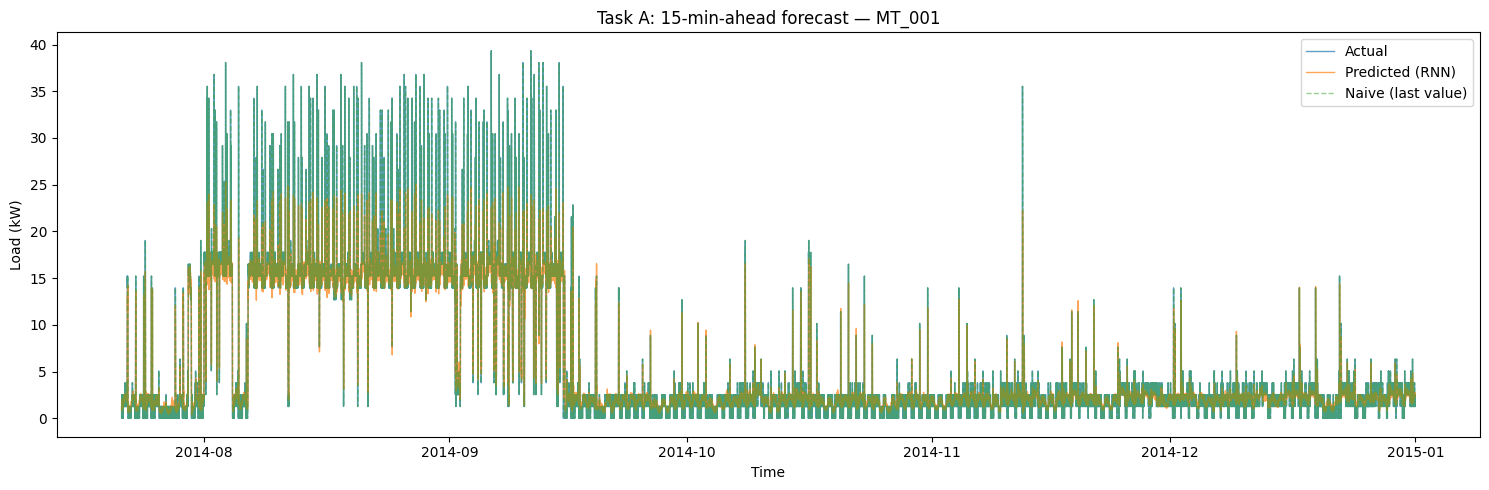

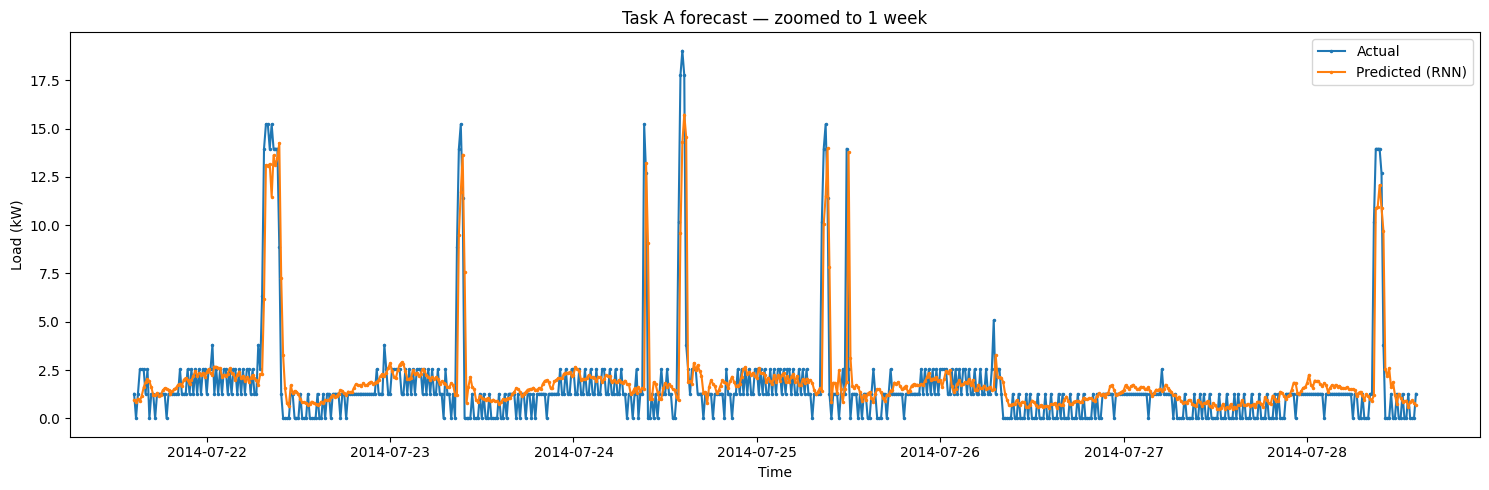

In [ ]:
import matplotlib.pyplot as plt

# Get corresponding timestamps for the test set (need to align with windowing offset)
test_timestamps = test["timestamp"].values[96:96 + len(y_true_kw)]  # input_len=96 offset

plt.figure(figsize=(15, 5))
plt.plot(test_timestamps, y_true_kw, label="Actual", alpha=0.7, linewidth=1)
plt.plot(test_timestamps, y_pred_kw, label="Predicted (RNN)", alpha=0.7, linewidth=1)
plt.plot(test_timestamps, naive_pred_kw, label="Naive (last value)", alpha=0.5, linewidth=1, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Load (kW)")
plt.title("Task A: 15-min-ahead forecast — MT_001")
plt.legend()
plt.tight_layout()
plt.show()

# Zoom into a smaller window (e.g. one week) since 96k+ points is unreadable
zoom_n = 672  # ~1 week at 15-min resolution
plt.figure(figsize=(15, 5))
plt.plot(test_timestamps[:zoom_n], y_true_kw[:zoom_n], label="Actual", marker=".", markersize=3)
plt.plot(test_timestamps[:zoom_n], y_pred_kw[:zoom_n], label="Predicted (RNN)", marker=".", markersize=3)
plt.xlabel("Time")
plt.ylabel("Load (kW)")
plt.title("Task A forecast — zoomed to 1 week")
plt.legend()
plt.tight_layout()
plt.show()

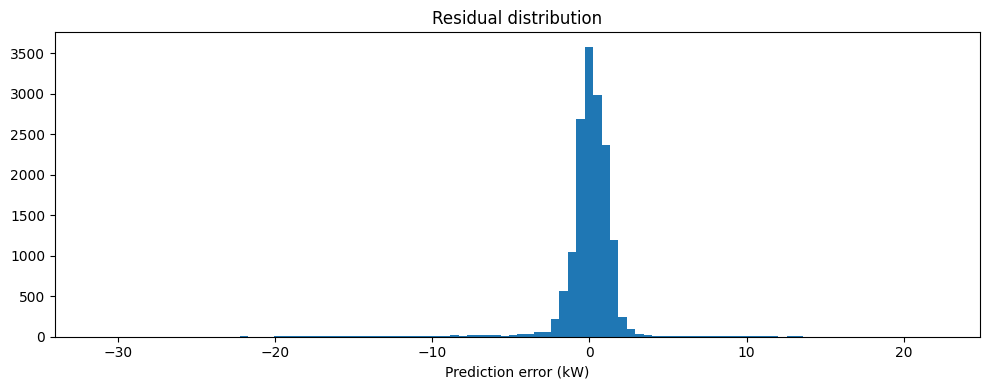

hour
9     2.117928
10    1.718567
7     1.650266
14    1.450614
18    1.330197
8     1.290296
11    1.284004
15    1.254207
12    1.019872
19    1.007200
13    0.947373
6     0.878649
17    0.873423
21    0.868093
22    0.832852
23    0.811713
16    0.793529
1     0.750983
20    0.745020
0     0.736385
5     0.712080
3     0.687916
4     0.669066
2     0.661052
Name: abs_error, dtype: float32


In [ ]:
residuals = (y_pred_kw - y_true_kw).flatten()

# Residual distribution
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=100)
plt.xlabel("Prediction error (kW)")
plt.title("Residual distribution")
plt.tight_layout()
plt.show()

# Error by hour of day — reveals if certain times are systematically harder
test_hours = test["hour_of_day"].values[96:96 + len(residuals)]
error_by_hour = pd.DataFrame({"hour": test_hours, "abs_error": np.abs(residuals)})
print(error_by_hour.groupby("hour")["abs_error"].mean().sort_values(ascending=False))

In [ ]:
results = {
    "client": "MT_001",
    "task": "A",
    "horizon_steps": 1,
    "mae_kw": float(mae),
    "rmse_kw": float(rmse),
    "mape_masked_pct": float(mape_masked),
    "naive_mae_kw": float(naive_mae),
    "naive_rmse_kw": float(naive_rmse),
    "mae_improvement_pct": float((1 - mae/naive_mae) * 100),
}
print(results)

# Append to a running results log for later comparison across tasks/clients
import json
results_path = "/content/drive/MyDrive/tfrecords/results_log.jsonl"
with open(results_path, "a") as f:
    f.write(json.dumps(results) + "\n")

{'client': 'MT_001', 'task': 'A', 'horizon_steps': 1, 'mae_kw': 1.0452746152877808, 'rmse_kw': 2.158190965652466, 'mape_masked_pct': 29.071819305419922, 'naive_mae_kw': 1.1775407791137695, 'naive_rmse_kw': 2.5615439414978027, 'mae_improvement_pct': 11.232405662536621}


## **Stacked LSTM**

In [30]:
def build_stacked_lstm_model(input_len: int, n_features: int, output_len: int,
                               units_1: int = 64, units_2: int = 32, dropout: float = 0.2):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_len, n_features)),
        tf.keras.layers.LSTM(units_1, return_sequences=True),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.LSTM(units_2, return_sequences=False),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(output_len),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model_A_lstm_stacked = build_stacked_lstm_model(96, n_features, output_len=1)
model_A_lstm_stacked.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
callbacks_A_lstm_stacked, log_dir_A_lstm_stacked = make_callbacks("task_A_lstm_stacked")

history_A_lstm_stacked = model_A_lstm_stacked.fit(
    train_ds_A,
    validation_data=val_ds_A,
    epochs=1000,
    callbacks=callbacks_A_lstm_stacked,
    verbose=1,
)
# starting time:
  # 07:42 to 7:55

Epoch 1/1000
   1148/Unknown 41s 31ms/step - loss: 0.4695 - mae: 0.4162

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.09267, saving model to /content/drive/MyDrive/logs/task_A_lstm_stacked/20260831-144232/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_A_lstm_stacked/20260831-144232/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 46s 35ms/step - loss: 0.2405 - mae: 0.2678 - val_loss: 0.0927 - val_mae: 0.1668 - learning_rate: 0.0010
Epoch 2/1000
1148/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2738 - mae: 0.2859
Epoch 2: val_loss improved from 0.09267 to 0.09129, saving model to /content/drive/MyDrive/logs/task_A_lstm_stacked/20260831-144232/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_A_lstm_stacked/20260831-144232/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 58s 17ms/step - loss: 0.1738 - mae: 0.2166 - val_loss: 0.0913 - val_mae: 0.1596 - learning_rate: 0.0010
Epoch 3/1000
1149/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2646 - mae: 0.2780
Epoch 3: val_loss did not impr

In [33]:
def evaluate_model_full(model, test_ds, load_scaler, feature_cols, test_df,
                         model_name: str, task_name: str = "A",
                         input_len: int = 96,
                         results_path: str = "/content/drive/MyDrive/tfrecords/results_log.jsonl"):

    # --- Predictions ---
    y_pred_scaled = model.predict(test_ds)
    y_true_scaled = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
    y_pred_kw = load_scaler.inverse_transform(y_pred_scaled)
    y_true_kw = load_scaler.inverse_transform(y_true_scaled)

    # --- Naive baseline ---
    X_test_arr = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)
    load_scaled_idx = feature_cols.index("load_scaled")
    naive_pred_kw = load_scaler.inverse_transform(
        X_test_arr[:, -1, load_scaled_idx].reshape(-1, 1)
    )

    # --- Metrics ---
    mae = np.mean(np.abs(y_pred_kw - y_true_kw))
    rmse = np.sqrt(np.mean((y_pred_kw - y_true_kw) ** 2))
    mask = np.abs(y_true_kw) > 0.1
    mape_masked = (np.mean(np.abs((y_true_kw[mask] - y_pred_kw[mask]) / y_true_kw[mask])) * 100
                   if mask.sum() > 0 else np.nan)
    naive_mae = np.mean(np.abs(naive_pred_kw - y_true_kw))
    naive_rmse = np.sqrt(np.mean((naive_pred_kw - y_true_kw) ** 2))

    print(f"\n{'='*50}\n{model_name.upper()} — Task {task_name}\n{'='*50}")
    print(f"MAE:  {mae:.4f} kW   (naive: {naive_mae:.4f} kW)")
    print(f"RMSE: {rmse:.4f} kW   (naive: {naive_rmse:.4f} kW)")
    print(f"MAPE (masked, |y|>0.1kW): {mape_masked:.2f}%")
    print(f"MAE improvement vs naive: {(1 - mae/naive_mae) * 100:.1f}%")
    print(f"RMSE improvement vs naive: {(1 - rmse/naive_rmse) * 100:.1f}%")

    # --- Log results ---
    results = {
        "client": "MT_001", "task": task_name, "model": model_name,
        "mae_kw": float(mae), "rmse_kw": float(rmse),
        "mape_masked_pct": float(mape_masked),
        "naive_mae_kw": float(naive_mae), "naive_rmse_kw": float(naive_rmse),
        "mae_improvement_pct": float((1 - mae/naive_mae) * 100),
        "rmse_improvement_pct": float((1 - rmse/naive_rmse) * 100),
    }
    with open(results_path, "a") as f:
        f.write(json.dumps(results) + "\n")

    # --- Timestamps aligned to test predictions ---
    timestamps = test_df["timestamp"].values[input_len:input_len + len(y_true_kw)]

    # --- Plot 1: Full test range ---
    plt.figure(figsize=(15, 4))
    plt.plot(timestamps, y_true_kw, label="Actual", alpha=0.7, linewidth=1)
    plt.plot(timestamps, y_pred_kw, label=f"Predicted ({model_name})", alpha=0.7, linewidth=1)
    plt.xlabel("Time"); plt.ylabel("Load (kW)")
    plt.title(f"{model_name} — Task {task_name} — Full test range")
    plt.legend(); plt.tight_layout(); plt.show()

    # --- Plot 2: 1-week zoom ---
    zoom_n = min(672, len(timestamps))
    plt.figure(figsize=(15, 4))
    plt.plot(timestamps[:zoom_n], y_true_kw[:zoom_n], label="Actual", marker=".", markersize=3)
    plt.plot(timestamps[:zoom_n], y_pred_kw[:zoom_n], label=f"Predicted ({model_name})", marker=".", markersize=3)
    plt.plot(timestamps[:zoom_n], naive_pred_kw[:zoom_n], label="Naive", linestyle="--", alpha=0.5)
    plt.xlabel("Time"); plt.ylabel("Load (kW)")
    plt.title(f"{model_name} — Task {task_name} — 1 week zoom")
    plt.legend(); plt.tight_layout(); plt.show()

    # --- Plot 3: Residual distribution ---
    residuals = (y_pred_kw - y_true_kw).flatten()
    plt.figure(figsize=(10, 4))
    plt.hist(residuals, bins=100)
    plt.xlabel("Prediction error (kW)"); plt.title(f"{model_name} — Residual distribution")
    plt.tight_layout(); plt.show()

    # --- Plot 4: Error by hour of day ---
    test_hours = test_df["hour_of_day"].values[input_len:input_len + len(residuals)]
    error_by_hour = pd.DataFrame({"hour": test_hours, "abs_error": np.abs(residuals)})
    hourly_mae = error_by_hour.groupby("hour")["abs_error"].mean()
    plt.figure(figsize=(10, 4))
    hourly_mae.plot(kind="bar")
    plt.xlabel("Hour of day"); plt.ylabel("Mean Absolute Error (kW)")
    plt.title(f"{model_name} — Error by hour of day")
    plt.tight_layout(); plt.show()

    return results, y_pred_kw, y_true_kw

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



LSTM_STACKED — Task A
MAE:  1.0220 kW   (naive: 1.1775 kW)
RMSE: 2.1476 kW   (naive: 2.5615 kW)
MAPE (masked, |y|>0.1kW): 28.34%
MAE improvement vs naive: 13.2%
RMSE improvement vs naive: 16.2%


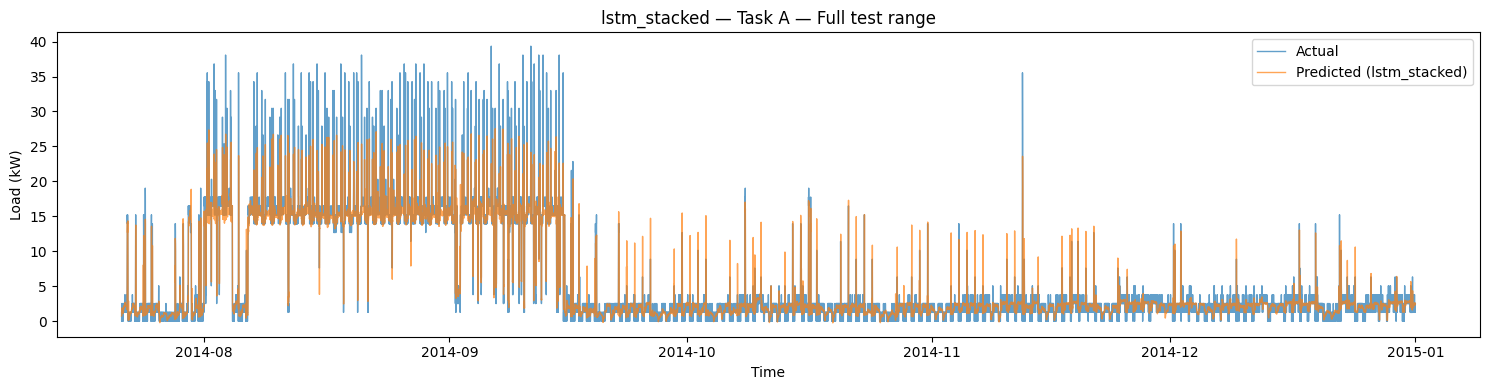

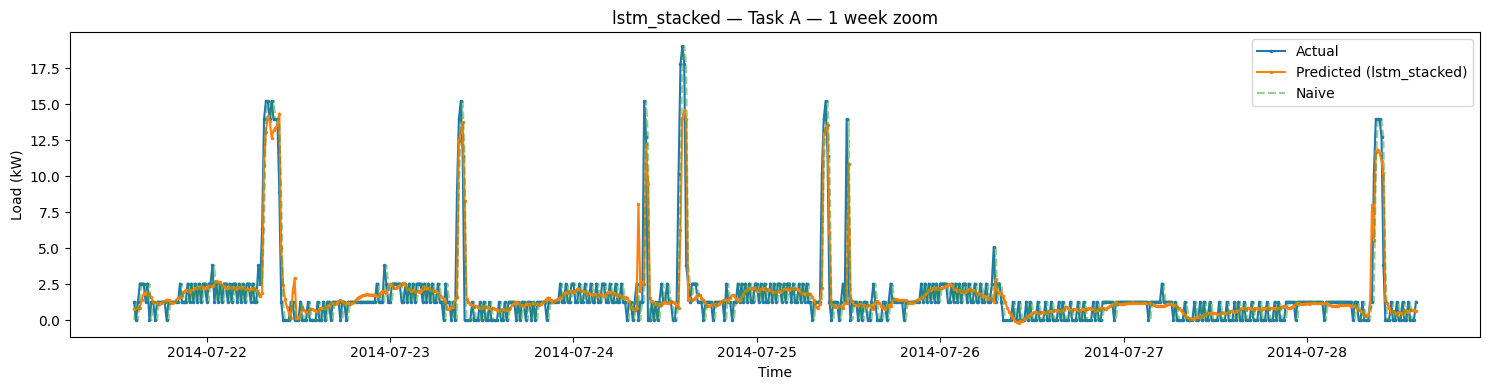

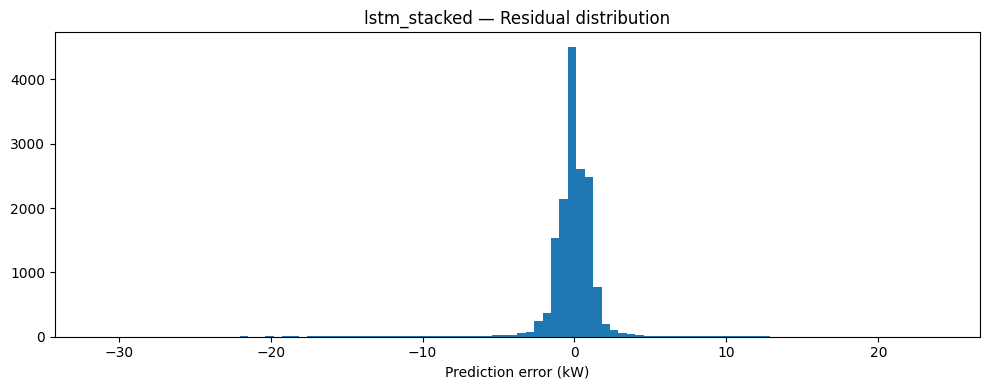

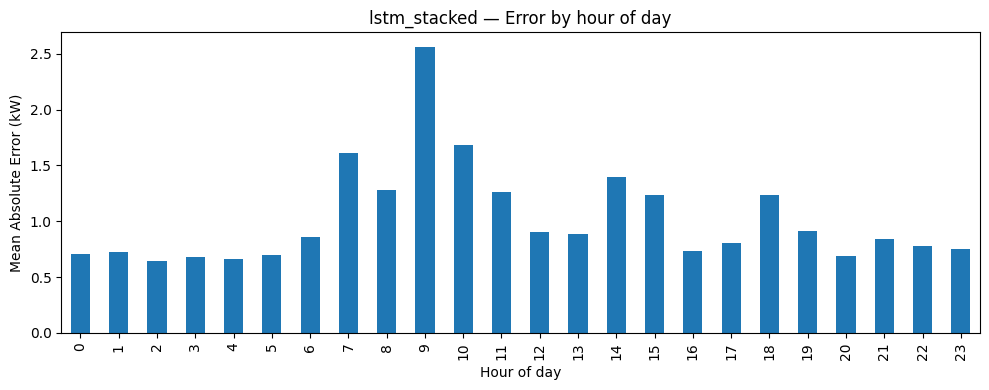

In [34]:
import json
results_lstm_stacked, y_pred_lstm_stacked, y_true_lstm_stacked = evaluate_model_full(
    model_A_lstm_stacked, test_ds_A, load_scaler, feature_cols, test,
    model_name="lstm_stacked", task_name="A"
)

### **GRU**

In [35]:
def build_gru_model(input_len: int, n_features: int, output_len: int, units: int = 32):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_len, n_features)),
        tf.keras.layers.GRU(units, return_sequences=False),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(output_len),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model_A_gru = build_gru_model(96, n_features, output_len=1)
model_A_gru.summary()

callbacks_A_gru, log_dir_A_gru = make_callbacks("task_A_GRU")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,577 (17.88 KB)

 Trainable params: 4,577 (17.88 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history_A_gru = model_A_gru.fit(
    train_ds_A,
    validation_data=val_ds_A,
    epochs=1000,
    callbacks=callbacks_A_gru,
    verbose=1,
)
# Starting Time: 7:56 to

Epoch 1/1000
   1150/Unknown 21s 17ms/step - loss: 0.3993 - mae: 0.3590

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.09673, saving model to /content/drive/MyDrive/logs/task_A_GRU/20260831-145637/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_A_GRU/20260831-145637/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - loss: 0.2026 - mae: 0.2308 - val_loss: 0.0967 - val_mae: 0.1711 - learning_rate: 0.0010
Epoch 2/1000
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2706 - mae: 0.2730
Epoch 2: val_loss improved from 0.09673 to 0.08929, saving model to /content/drive/MyDrive/logs/task_A_GRU/20260831-145637/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_A_GRU/20260831-145637/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - loss: 0.1687 - mae: 0.2057 - val_loss: 0.0893 - val_mae: 0.1555 - learning_rate: 0.0010
Epoch 3/1000
1147/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2578 - mae: 0.2657
Epoch 3: val_loss improved from 0.08929 to 0.08866, saving model t

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

GRU — Task A
MAE:  0.9973 kW   (naive: 1.1775 kW)
RMSE: 2.0873 kW   (naive: 2.5615 kW)
MAPE (masked, |y|>0.1kW): 27.23%
MAE improvement vs naive: 15.3%
RMSE improvement vs naive: 18.5%


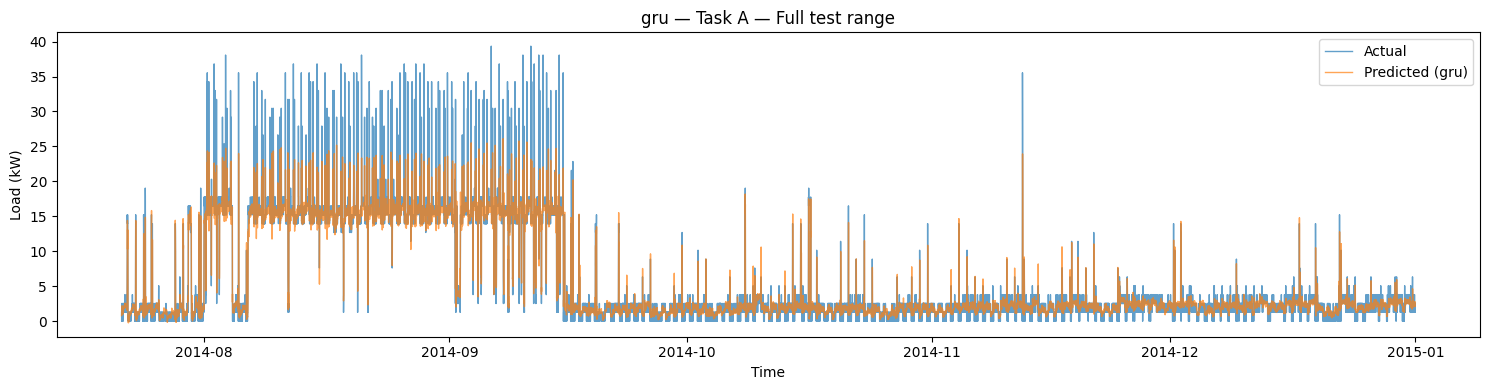

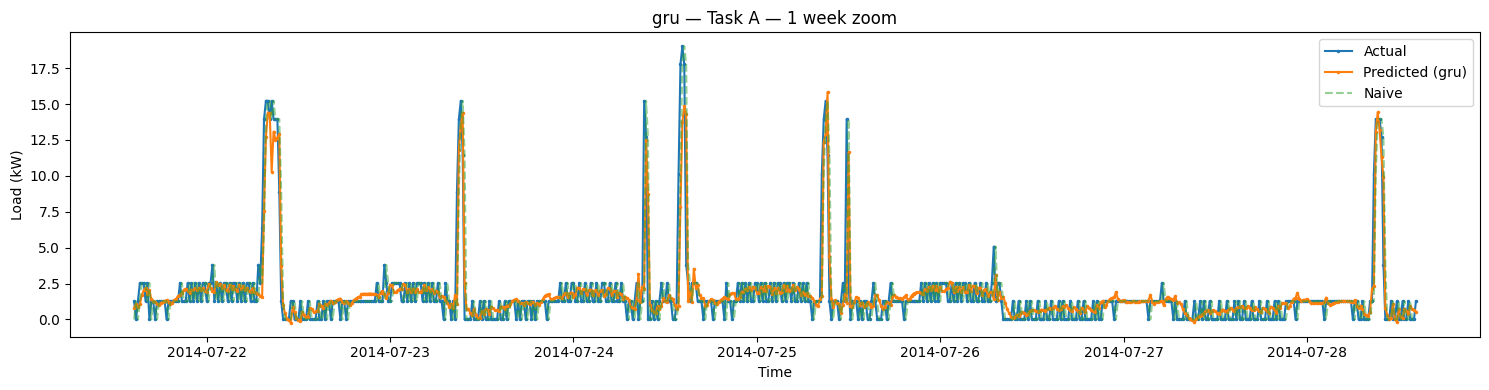

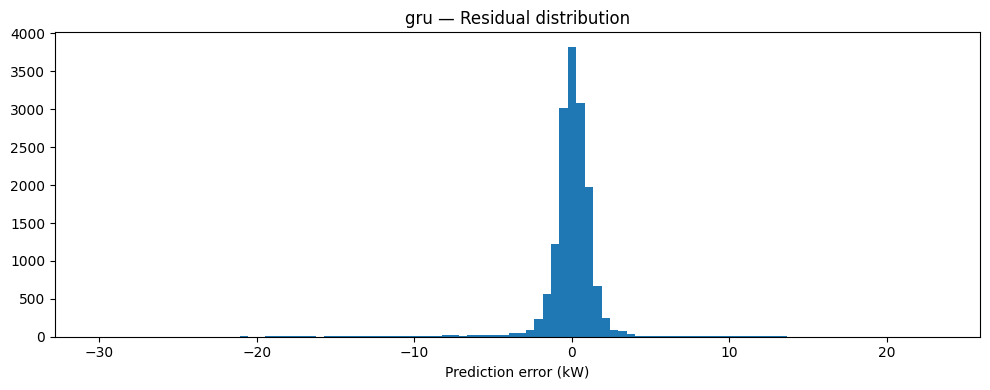

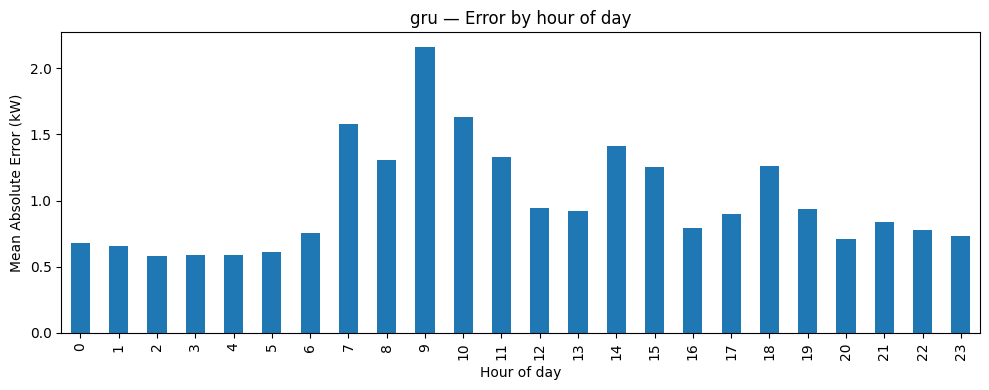

In [37]:
results_gru, y_pred_gru, y_true_gru = evaluate_model_full(
    model_A_gru, test_ds_A, load_scaler, feature_cols, test,
    model_name="gru", task_name="A"
)

### **Transformer**

In [30]:
class PositionalEncoding(tf.keras.layers.Layer):

  def __init__(self, seq_len, d_model, **kwargs):
    super().__init__(**kwargs)
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    self.pe = tf.constant(pe, dtype=tf.float32)

  def call(self, x):
    return x + self.pe


def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout=0.1):
  attn = tf.keras.layers.MultiHeadAttention(
      num_heads=num_heads, key_dim=d_model // num_heads
  )(x, x)
  attn = tf.keras.layers.Dropout(dropout)(attn)
  x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + attn)

  ff = tf.keras.layers.Dense(ff_dim, activation="relu")(x)
  ff = tf.keras.layers.Dense(d_model)(ff)
  ff = tf.keras.layers.Dropout(dropout)(ff)
  x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + ff)
  return x


def build_transformer_model(
    input_len: int,
    n_features: int,
    output_len: int,
    d_model: int = 32,
    num_heads: int = 4,
    ff_dim: int = 64,
    num_blocks: int = 2,
    dropout: float = 0.1,
):
  inputs = tf.keras.layers.Input(shape=(input_len, n_features))
  x = tf.keras.layers.Dense(d_model)(inputs)
  x = PositionalEncoding(input_len, d_model)(x)

  for _ in range(num_blocks):
    x = transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout)

  x = tf.keras.layers.GlobalAveragePooling1D()(x)
  x = tf.keras.layers.Dense(16, activation="relu")(x)
  outputs = tf.keras.layers.Dense(output_len)(x)

  model = tf.keras.Model(inputs, outputs)
  model.compile(optimizer="adam", loss="mse", metrics=["mae"])
  return model


model_A_transformer = build_transformer_model(
    input_len=96, n_features=n_features, output_len=1
)
model_A_transformer.summary()

callbacks_A_trans, log_dir_A_trans = make_callbacks("task_A_transformer")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96, 32)    │        288 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 96, 32)    │          0 │ dense[0][0]       │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 96, 32)    │      4,224 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 32)    │          0 │ positional_encod… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 96, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 96, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96, 32)    │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 96, 32)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 96, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 96, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 96, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 96, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 96, 32)    │      2,080 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 96, 32)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 96, 32)    │          0 │ layer_normalizat

 Total params: 17,921 (70.00 KB)

 Trainable params: 17,921 (70.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_A_transformer = model_A_transformer.fit(
    train_ds_A,
    validation_data=val_ds_A,
    epochs=1000,
    callbacks=callbacks_A_trans,
    verbose=1,
)
# 10:19

Epoch 1/1000
   1150/Unknown 49s 30ms/step - loss: 0.5250 - mae: 0.4414

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.09450, saving model to /content/drive/MyDrive/logs/task_A_transformer/20260831-171936/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_A_transformer/20260831-171936/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - loss: 0.2507 - mae: 0.2648 - val_loss: 0.0945 - val_mae: 0.1685 - learning_rate: 0.0010
Epoch 2/1000
1143/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2735 - mae: 0.2762
Epoch 2: val_loss improved from 0.09450 to 0.09119, saving model to /content/drive/MyDrive/logs/task_A_transformer/20260831-171936/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_A_transformer/20260831-171936/best_model.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - loss: 0.1717 - mae: 0.2103 - val_loss: 0.0912 - val_mae: 0.1641 - learning_rate: 0.0010
Epoch 3/1000
1145/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2701 - mae: 0.2770
Epoch 3: val_loss improved from 0.091

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



TRANSFORMER — Task A
MAE:  0.9690 kW   (naive: 1.1775 kW)
RMSE: 2.0522 kW   (naive: 2.5615 kW)
MAPE (masked, |y|>0.1kW): 29.31%
MAE improvement vs naive: 17.7%
RMSE improvement vs naive: 19.9%


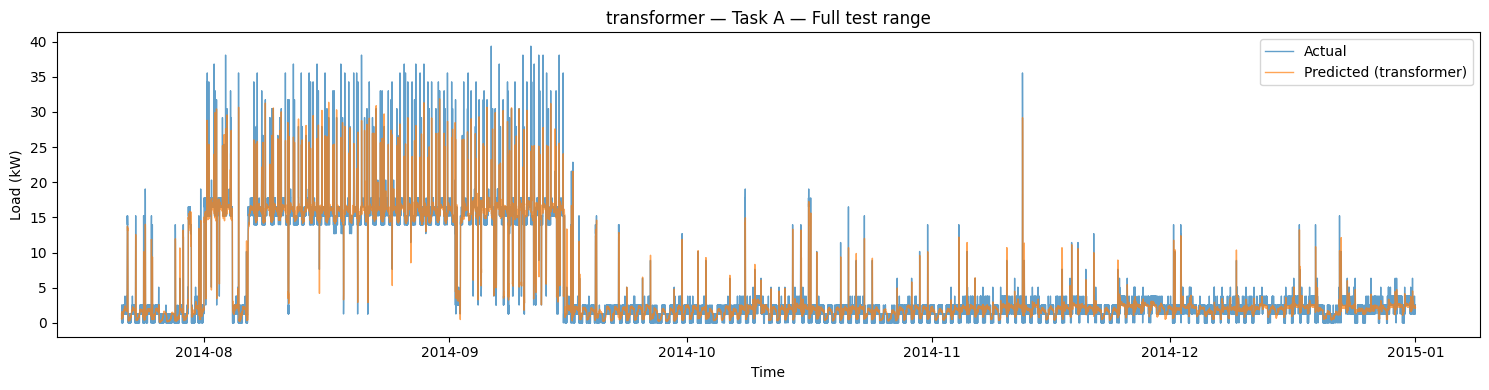

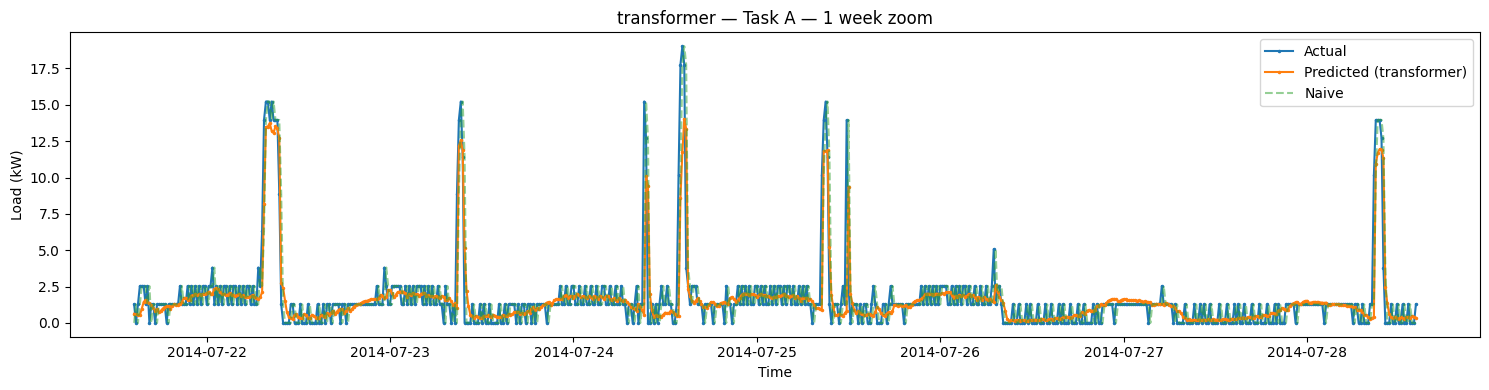

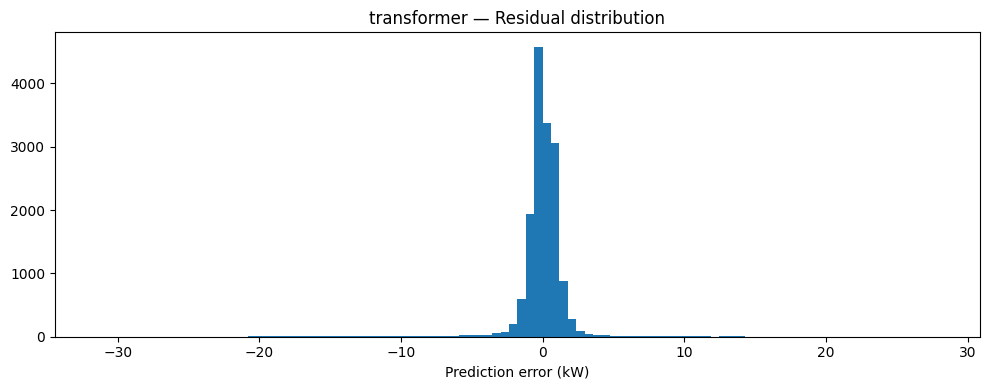

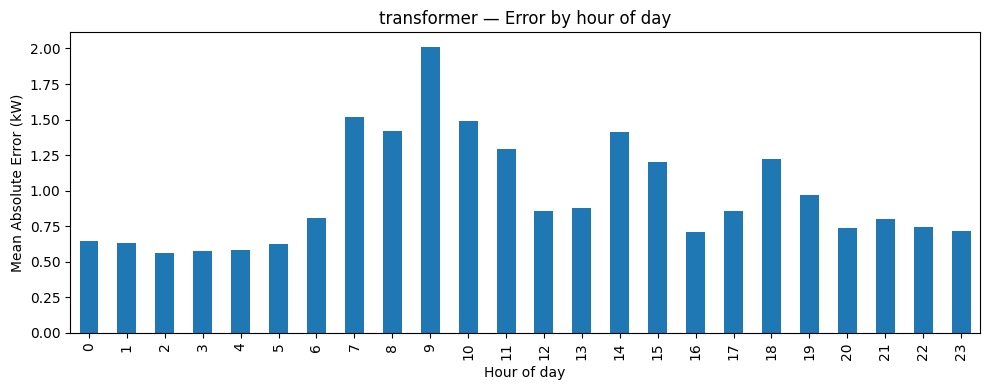

In [35]:
import json
results_trans, y_pred_trans, y_true_trans = evaluate_model_full(
    model=model_A_transformer, test_ds=test_ds_A,
    load_scaler=load_scaler,
    feature_cols=feature_cols,
    test_df=test,
    model_name="transformer",
    task_name="A",
)